# Correlation Analysis

## Tujuan

Notebook ini bertujuan untuk mengetahui hubungan antar variabel numerik pada dataset hasil scraping Shopee.

Analisis dilakukan menggunakan dua metode:

- Pearson Correlation
- Spearman Correlation

Hasil analisis ini akan menjadi dasar dalam pemilihan fitur pada tahap regresi, klasifikasi, dan clustering.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
df = pd.read_csv("../data/processed/ecommerce.csv")

Pilih Variabel Numerik

In [13]:
features = [
    "price_avg",
    "discount_percent",
    "rating",
    "review_count",
    "sold",
    "seller_rating",
    "seller_followers",
    "seller_product",
    "seller_response_rate",
    "seller_age"
]

corr_df = df[features]

## Pearson Correlation

Pearson Correlation digunakan untuk mengukur hubungan linear antar variabel.

Nilai korelasi berada pada rentang:

- -1 : hubungan negatif sempurna
- 0 : tidak ada hubungan
- +1 : hubungan positif sempurna

In [14]:
pearson = corr_df.corr(method="pearson")

pearson

,price_avg,discount_percent,rating,review_count,sold,seller_rating,seller_followers,seller_product,seller_response_rate,seller_age
price_avg,1.000000,-0.360155,0.311265,-0.164137,-0.311025,-0.115386,0.016966,-0.060731,0.138175,0.016476
discount_percent,-0.360155,1.000000,-0.284313,0.104344,0.237091,0.040779,-0.045663,-0.098337,-0.059395,-0.001851
rating,0.311265,-0.284313,1.000000,-0.020277,-0.141100,0.060711,0.108777,0.130762,0.069965,-0.173109
review_count,-0.164137,0.104344,-0.020277,1.000000,0.654874,0.596509,0.484819,-0.021355,-0.027707,-0.047645
sold,-0.311025,0.237091,-0.141100,0.654874,1.000000,0.437126,0.406299,0.031015,-0.118174,-0.034387
seller_rating,-0.115386,0.040779,0.060711,0.596509,0.437126,1.000000,0.840170,0.105913,-0.002096,-0.110693
seller_followers,0.016966,-0.045663,0.108777,0.484819,0.406299,0.840170,1.000000,0.113126,0.040034,-0.091122
seller_product,-0.060731,-0.098337,0.130762,-0.021355,0.031015,0.105913,0.113126,1.000000,-0.034744,-0.138022
seller_response_rate,0.138175,-0.059395,0.069965,-0.027707,-0.118174,-0.002096,0.040034,-0.034744,1.000000,0.049732
seller_age,0.016476,-0.001851,-0.173109,-0.047645,-0.034387,-0.110693,-0.091122,-0.138022,0.049732,1.000000


Heatmap

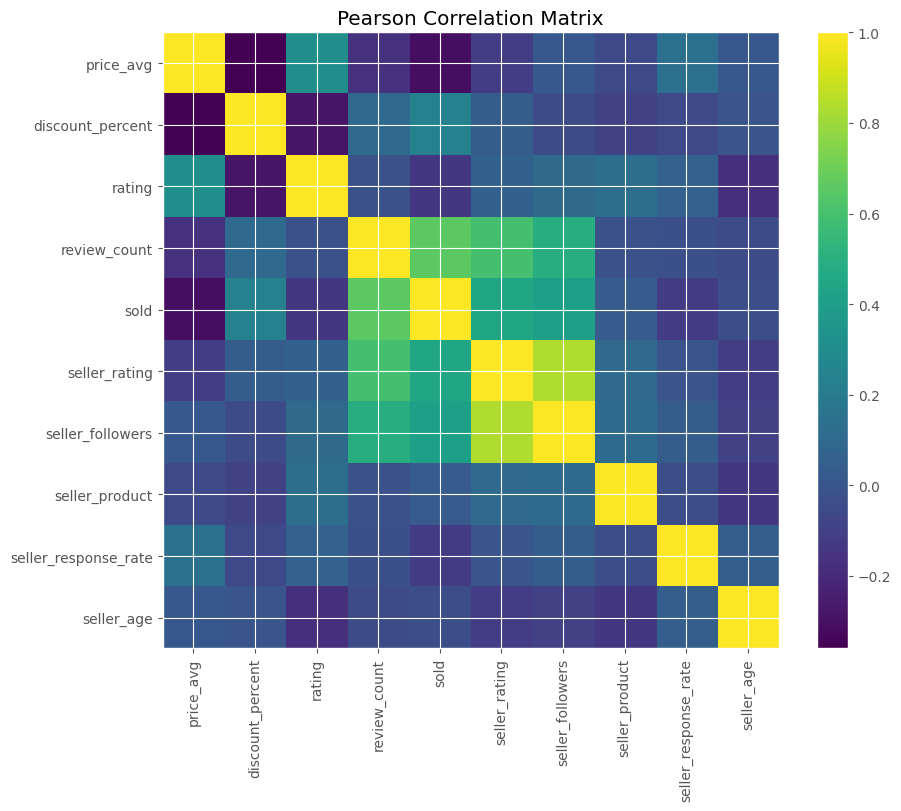

In [15]:
plt.figure(figsize=(10,8))

plt.imshow(pearson)

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.colorbar()

plt.title("Pearson Correlation Matrix")

plt.show()

----------------------------------------------------
| Nilai Korelasi | Interpretasi                    |
| -------------: | ------------------------------- |
|    0.80 – 1.00 | Sangat kuat                     |
|    0.60 – 0.79 | Kuat                            |
|    0.40 – 0.59 | Sedang                          |
|    0.20 – 0.39 | Lemah                           |
|    0.00 – 0.19 | Sangat lemah / hampir tidak ada |
|  Nilai negatif | Hubungan berlawanan arah        |
----------------------------------------------------

## Spearman Correlation

Spearman Correlation digunakan untuk mengukur hubungan monotonic antar variabel dan lebih tahan terhadap outlier dibanding Pearson Correlation.

In [16]:
spearman = corr_df.corr(method="spearman")

spearman

,price_avg,discount_percent,rating,review_count,sold,seller_rating,seller_followers,seller_product,seller_response_rate,seller_age
price_avg,1.000000,-0.397048,0.455175,-0.442131,-0.475694,-0.235172,-0.000953,0.081354,0.130068,0.018773
discount_percent,-0.397048,1.000000,-0.229681,0.348568,0.343760,0.241908,0.135525,-0.111194,0.007712,0.005594
rating,0.455175,-0.229681,1.000000,-0.474059,-0.462606,-0.036792,0.032858,0.292833,-0.008151,-0.023015
review_count,-0.442131,0.348568,-0.474059,1.000000,0.981719,0.561760,0.441475,-0.086506,-0.012829,-0.047807
sold,-0.475694,0.343760,-0.462606,0.981719,1.000000,0.549658,0.421480,-0.103889,-0.031762,-0.030219
seller_rating,-0.235172,0.241908,-0.036792,0.561760,0.549658,1.000000,0.874505,0.370263,0.010209,-0.119147
seller_followers,-0.000953,0.135525,0.032858,0.441475,0.421480,0.874505,1.000000,0.317138,0.058595,-0.131899
seller_product,0.081354,-0.111194,0.292833,-0.086506,-0.103889,0.370263,0.317138,1.000000,-0.097731,-0.198577
seller_response_rate,0.130068,0.007712,-0.008151,-0.012829,-0.031762,0.010209,0.058595,-0.097731,1.000000,-0.048716
seller_age,0.018773,0.005594,-0.023015,-0.047807,-0.030219,-0.119147,-0.131899,-0.198577,-0.048716,1.000000


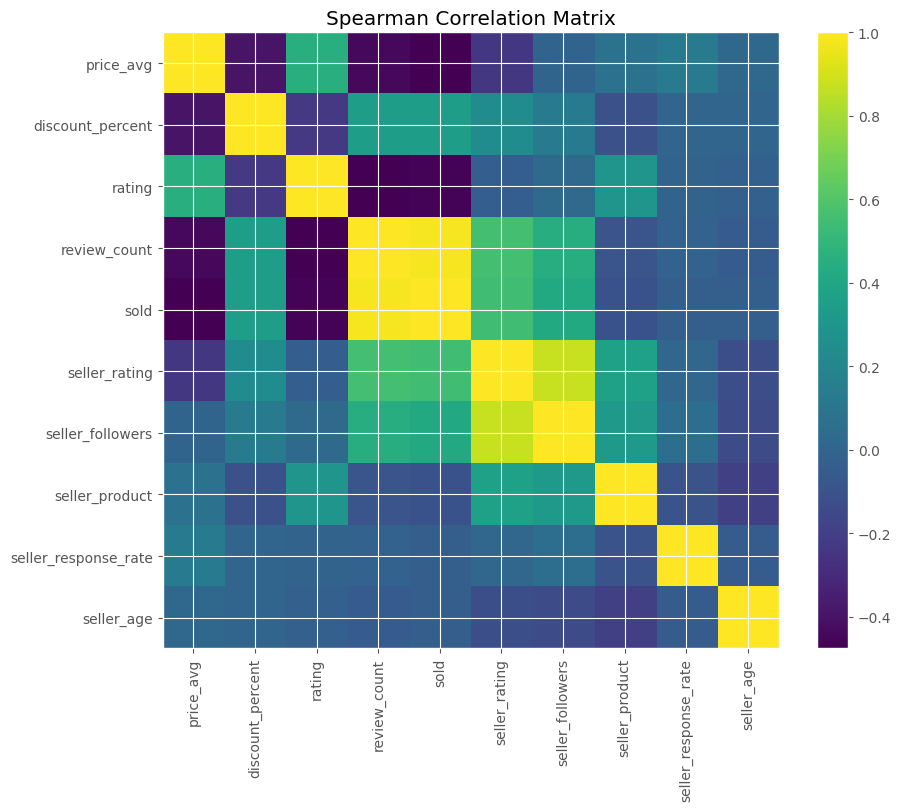

In [17]:
plt.figure(figsize=(10,8))

plt.imshow(spearman)

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.colorbar()

plt.title("Spearman Correlation Matrix")

plt.show()

In [18]:
pearson["sold"].sort_values(ascending=False)

sold                    1.000000
review_count            0.654874
seller_rating           0.437126
seller_followers        0.406299
discount_percent        0.237091
seller_product          0.031015
seller_age             -0.034387
seller_response_rate   -0.118174
rating                 -0.141100
price_avg              -0.311025
Name: sold, dtype: float64

In [19]:
spearman["sold"].sort_values(ascending=False)

sold                    1.000000
review_count            0.981719
seller_rating           0.549658
seller_followers        0.421480
discount_percent        0.343760
seller_age             -0.030219
seller_response_rate   -0.031762
seller_product         -0.103889
rating                 -0.462606
price_avg              -0.475694
Name: sold, dtype: float64

##  Scatter Plot

Saya hanya akan membuat scatter plot untuk 3 pasangan variabel dengan korelasi tertinggi.

Harga vs Sold

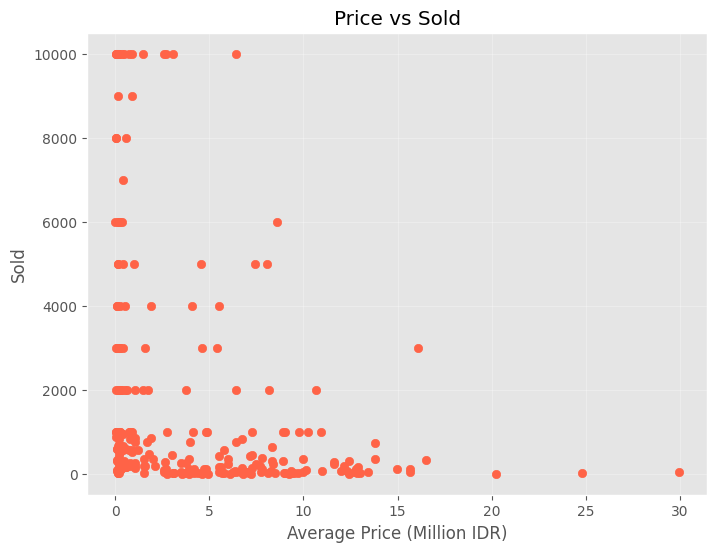

In [20]:
plt.figure(figsize=(8,6))

# Konversi ke juta rupiah
price_million = df["price_avg"] / 1_000_000

plt.scatter(price_million, df["sold"], color="tomato")

plt.title("Price vs Sold")
plt.xlabel("Average Price (Million IDR)")
plt.ylabel("Sold")

plt.grid(True, alpha=0.3)

plt.show()

Review vs Sold

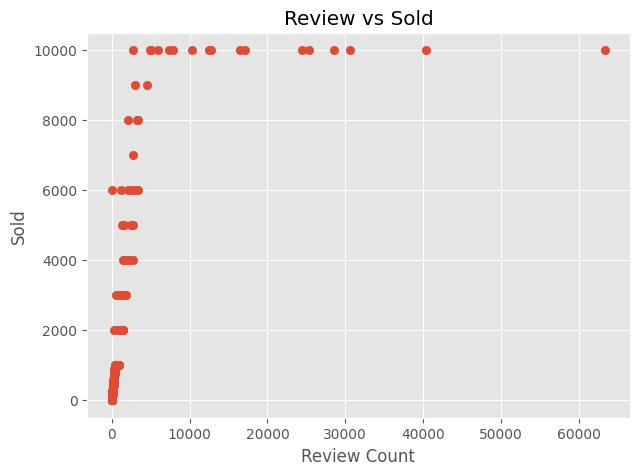

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(df["review_count"], df["sold"])

plt.xlabel("Review Count")

plt.ylabel("Sold")

plt.title("Review vs Sold")

plt.show()

Follower vs Sold

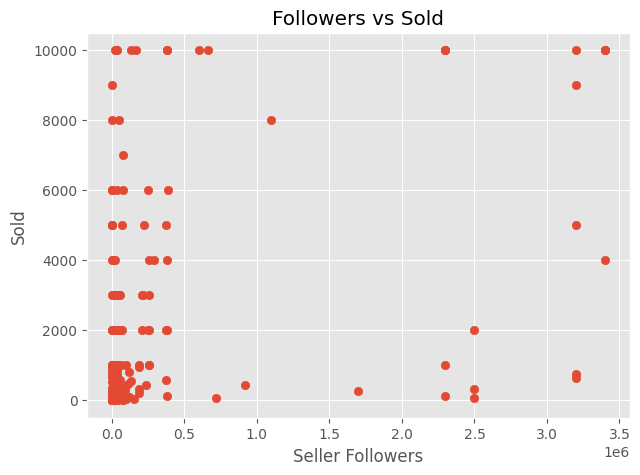

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(df["seller_followers"], df["sold"])

plt.xlabel("Seller Followers")

plt.ylabel("Sold")

plt.title("Followers vs Sold")

plt.show()